# HDT2 - Modelado de un sistema real como k-armed bandit

**Dominio elegido:** optimización de la llamada a la acción (CTA, *call-to-action*) en la página de producto de un sitio de e-commerce.

Cada vez que un visitante carga la página de producto, el sistema debe decidir qué texto/diseño de botón de compra mostrarle (ej. "Comprar ahora", "Añadir al carrito", "Comprar con 1 clic"). El objetivo es maximizar la tasa de conversión sin dedicar tráfico de más a variantes que resultan malas.

## 1. Modelado formal

### 1.a Definición de los k brazos

Los brazos son un conjunto finito y predefinido de **variantes de CTA** que el equipo de producto diseñó de antemano, por ejemplo:

| Brazo | Variante |
|---|---|
| $a_1$ | "Comprar ahora" (botón rojo) |
| $a_2$ | "Añadir al carrito" (botón azul) |
| $a_3$ | "Comprar con 1 clic" (botón verde) |
| $a_4$ | "Ver oferta" (botón naranja) |
| $a_5$ | "Reservar ahora" (botón negro) |

$k=5$ en este ejemplo, pero el análisis es general para cualquier $k$ pequeño.

El conjunto de acciones es finito y discreto porque:

- Cada variante requiere trabajo de diseño/copywriting y una implementación de frontend concreta, no existe un continuo de "CTAs posibles" que el sistema pueda generar por sí mismo en tiempo real.
- El equipo de producto/legal debe aprobar cada texto y diseño antes de ponerlo en producción (tono de marca, cumplimiento de normativas de publicidad), lo que impone una lista cerrada y pequeña de variantes válidas.
- Mostrar más de un puñado de variantes simultáneamente fragmentaría el tráfico y volvería estadísticamente inviable distinguir cuál es mejor en un tiempo razonable.

Cada "tirada" del bandit corresponde a una impresión de página (una visita), y la acción es la variante de CTA que el sistema decide mostrarle a ese visitante.

### 1.b Diseño de la función de recompensa

**Qué se mide:** la recompensa $R_t$ es binaria: $R_t = 1$ si el visitante que vio la variante completa una compra en esa sesión, $R_t = 0$ si no.

**Cómo se mide:** cada visita se etiqueta con la variante mostrada y se cruza contra el evento de conversión registrado en el sistema de analítica/checkout dentro de una ventana de sesión.

**Supuesto distribucional:** la recompensa no es gaussiana, es Bernoulli: $R_t \sim \text{Bernoulli}(q_*(a))$, donde $q_*(a)$ es la tasa de conversión verdadera de la variante $a$. Argumentos:

- El resultado de cada visita es estrictamente binario (compra / no compra), no una magnitud continua con ruido aditivo simétrico.
- Una distribución gaussiana asignaría probabilidad positiva a recompensas negativas o mayores a 1, lo cual no tiene sentido en este dominio.
- El promedio muestral de recompensas Bernoulli converge a una tasa de conversión, que es exactamente la cantidad de negocio que queremos estimar y optimizar.

Si se quisiera modelar el valor monetario de la compra, ahí sí podría justificarse una distribución continua, pero para este caso se usaría la formulación binaria de conversión.

### 1.c Análisis de estacionariedad

Los valores verdaderos $q_*(a)$ no son estacionarios, cambian con el tiempo por varias razones:

- **Estacionalidad de corto plazo:** el comportamiento de compra varía por día de la semana, hora del día y campañas de marketing activas.
- **Fatiga de variante:** usuarios recurrentes se acostumbran a un CTA repetido y su efectividad decae con la exposición repetida.
- **Cambios de catálogo/competencia:** cambios de precio, stock o competidores alteran la sensibilidad del usuario al mensaje del CTA.
- **Escala temporal:** estos cambios ocurren en horizontes de días a semanas, no de milisegundos ni de años; es razonable asumir que $q_*(a)$ es aproximadamente constante dentro de una sesión de tráfico de unas pocas horas, pero deriva de forma apreciable semana a semana.

**Implicación para la regla de actualización:** con un entorno no estacionario, el promedio muestral simple pondera igual una observación de hace tres meses que una de ayer, y por lo tanto se adapta demasiado lento a la deriva. Es preferible una regla de actualización de paso constante $\alpha$ (ver sección 2.b), que da más peso a las observaciones recientes y "olvida" gradualmente el pasado distante — exactamente el comportamiento que exige un $q_*(a)$ que cambia con el tiempo.

### 1.d Restricciones de exploración

Explorar no es gratis en este dominio:

- **Costo económico directo:** cada visitante que ve una variante subóptima es una conversión potencialmente perdida; con márgenes conocidos, cada punto porcentual de tasa de conversión sacrificado por explorar se traduce directamente en ingresos no percibidos.
- **Riesgo reputacional/de marca:** una variante mal diseñada (ej. texto agresivo tipo "¡Compra ya o piérdelo!") puede dañar la percepción de marca aunque convierta bien a corto plazo; el equipo legal/de marca limita qué variantes son elegibles de antemano (ver 1.a), y a menudo exige un tope máximo de tráfico exploratorio (ej. no más de 10-20% del tráfico total en variantes no probadas).
- **Restricción regulatoria:** en jurisdicciones con leyes de protección al consumidor (ej. UE), ciertos patrones de CTA considerados "dark patterns" (presión indebida de compra) están prohibidos, lo cual reduce aún más el conjunto de brazos explorables.
- **Costo de varianza en reportes de negocio:** el equipo de finanzas necesita que la tasa de conversión agregada sea razonablemente predecible mes a mes; demasiada exploración introduce ruido que dificulta el forecasting.

Estas restricciones justifican un $\varepsilon$ pequeño y una fracción de tráfico exploratorio acotada, en vez de una exploración agresiva tipo UCB con constante alta.

## 2. Estrategia propuesta

### 2.a Estrategia de selección de acción

Se propone **$\varepsilon$-greedy con $\varepsilon = 0.1$**.

Justificación:

- Es simple de auditar y explicar a stakeholders no técnicos, algo valioso dado que hay restricciones regulatorias y de marca sobre cuánto se puede explorar.
- $\varepsilon = 0.1$ mantiene el tráfico exploratorio dentro del tope de negocio típico (~10%), sin dejar de garantizar exploración continua de las 5 variantes — necesaria porque el entorno es no estacionario y $q_*(a)$ puede reordenarse con el tiempo, por ejemplo una variante ganadora hoy puede dejar de serlo en un mes).
- Se descarta UCB porque su exploración depende de un término $c\sqrt{\ln t / N_t(a)}$ que decrece con $t$; en un entorno no estacionario esa exploración decreciente es indeseable — UCB terminaría "confiando" demasiado en estimaciones viejas de conversión que ya no reflejan la realidad actual, exactamente el problema que se busca evitar.

### 2.b Regla de actualización de estimaciones

Se usa **paso constante** $\alpha = 0.1$ en vez de promedio muestral ($1/n$):

$$Q_{n+1}(a) = Q_n(a) + \alpha \left[ R_n - Q_n(a) \right]$$

Justificación ligada a 1.c: como $q_*(a)$ deriva en escalas de días/semanas, cada nueva observación debe pesar más que una observación antigua. El paso constante produce un promedio exponencialmente ponderado que da peso $\alpha(1-\alpha)^{n-i}$ a la observación $i$-ésima, decayendo geométricamente hacia el pasado — esto hace que el sistema "olvide" activamente conversión histórica obsoleta y se adapte a la deriva del entorno, algo que el promedio muestral no puede hacer una vez que $n$ es grande.

### 2.c Ejemplo numérico

Se simulan 6 observaciones (3 por brazo) para dos variantes: $a_1$ = "Comprar ahora" y $a_2$ = "Añadir al carrito". Valor inicial neutro $Q_1(a) = 0.5$ para ambos brazos, $\alpha = 0.1$.

In [1]:
import matplotlib.pyplot as plt

alpha = 0.1
Q = {"a1": 0.5, "a2": 0.5}

observaciones = [
    (1, "a1", 1),
    (2, "a2", 0),
    (3, "a1", 0),
    (4, "a2", 1),
    (5, "a1", 1),
    (6, "a2", 0),
]

historial = {"a1": [Q["a1"]], "a2": [Q["a2"]]}
pasos = {"a1": [1], "a2": [1]}

print(f"{'t':>2} {'accion':>6} {'R':>2} {'Q_a1':>8} {'Q_a2':>8}")
print(f"{'-':>2} {'-':>6} {'-':>2} {Q['a1']:>8.4f} {Q['a2']:>8.4f}")

for t, accion, r in observaciones:
    Q[accion] = Q[accion] + alpha * (r - Q[accion])
    historial[accion].append(Q[accion])
    pasos[accion].append(len(historial[accion]))
    print(f"{t:>2} {accion:>6} {r:>2} {Q['a1']:>8.4f} {Q['a2']:>8.4f}")

 t accion  R     Q_a1     Q_a2
 -      -  -   0.5000   0.5000
 1     a1  1   0.5500   0.5000
 2     a2  0   0.5500   0.4500
 3     a1  0   0.4950   0.4500
 4     a2  1   0.4950   0.5050
 5     a1  1   0.5455   0.5050
 6     a2  0   0.5455   0.4545


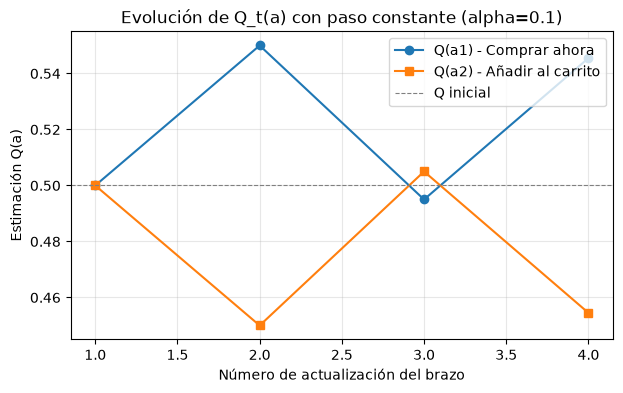

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(pasos["a1"], historial["a1"], marker="o", label="Q(a1) - Comprar ahora")
plt.plot(pasos["a2"], historial["a2"], marker="s", label="Q(a2) - Añadir al carrito")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Q inicial")
plt.xlabel("Número de actualización del brazo")
plt.ylabel("Estimación Q(a)")
plt.title("Evolución de Q_t(a) con paso constante (alpha=0.1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Lectura del resultado:**

- $a_1$ recibe recompensas $1, 0, 1$ y su estimación sube de $0.5 \to 0.55 \to 0.495 \to 0.5455$: la tendencia es al alza porque 2 de 3 observaciones fueron conversión.
- $a_2$ recibe recompensas $0, 1, 0$ y su estimación baja de $0.5 \to 0.45 \to 0.505 \to 0.4545$: la tendencia es a la baja porque 2 de 3 observaciones fueron no-conversión.
- Con solo 3 observaciones por brazo la estimación todavía no ha convergido a un valor estable; se necesitarían más tiradas para que $Q_t(a)$ se acerque a $q_*(a)$. Sin embargo el patrón ya es visible: cada actualización desplaza $Q_t(a)$ un $10\%$ de la distancia hacia la recompensa observada, lo cual es justo el comportamiento de "adaptación con memoria corta" buscado para un entorno no estacionario — si $q_*(a_2)$ mejorara dentro de un mes, la estimación lo reflejaría en pocas docenas de visitas en vez de arrastrar indefinidamente el promedio histórico completo.